In [1]:
import qn
qn.config(globals())

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import muldataframe as md
MulDataFrame = md.MulDataFrame

In [129]:
df = pd.read_csv('../muldataframe_paper/replicate/airport-codes.csv')

In [130]:
sum(df['coordinates'].isna())

0

In [131]:
df = df.query('type != "closed"')

In [134]:
df['type'] = [x.split('_')[0] if 'airport' in x else x for x in df['type']]
df['type'].value_counts()

type
small            41570
heliport         20946
medium            4713
seaplane_base     1189
large              475
balloonport         58
Name: count, dtype: int64

In [133]:
df['iso_country'].value_counts().head(50)

iso_country
US    24735
BR     6959
JP     3149
AU     2597
CA     2331
MX     2043
FR     1555
RU     1377
KR     1365
DE     1235
GB     1154
AR      901
IT      807
CO      716
CN      661
ZA      624
PH      598
IN      594
VE      592
ID      574
PG      560
ES      523
CL      493
KE      370
TR      356
CZ      348
EC      344
PL      313
CD      276
NZ      271
NO      266
IR      265
AE      252
NL      235
SE      216
TZ      207
BO      204
UA      197
PT      193
PE      180
AT      174
PK      164
KZ      162
BE      159
SA      156
ZW      149
CR      140
GR      137
HN      135
EG      133
Name: count, dtype: int64

In [135]:
df['latitude'] = [float(x.split(',')[0])
                  for x in df['coordinates']]
df['longitude'] = [float(x.split(',')[1])
                  for x in df['coordinates']]

In [136]:
vf = df[['ident','elevation_ft','latitude','longitude']].set_index('ident')
vf = vf.rename(columns={'elevation_ft':'elevation'})

In [247]:
nf = df[['ident','type','name','iso_country']].set_index('ident')
# 
nf = nf.rename(columns={'iso_country':'country'})
nm = nf[['name']]
nm['short'] = [x.split(' ')[0] for x in nm['name']]
nf['name'] = nm['short']
names = {}
for _, row in nm.iterrows():
    names[row.name] = row['name']

/var/folders/fh/dw4ym82j08l67xt8ndms1f_c0000gn/T/ipykernel_91169/3172484459.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nm['short'] = [x.split(' ')[0] for x in nm['name']]


In [248]:
names

{'00A': 'Total RF Heliport',
 '00AA': 'Aero B Ranch Airport',
 '00AK': 'Lowell Field',
 '00AL': 'Epps Airpark',
 '00AN': 'Katmai Lodge Airport',
 '00AS': 'Fulton Airport',
 '00AZ': 'Cordes Airport',
 '00CA': 'Goldstone (GTS) Airport',
 '00CL': 'Williams Ag Airport',
 '00CN': 'Kitchen Creek Helibase Heliport',
 '00FA': 'Grass Patch Airport',
 '00FL': 'River Oak Airport',
 '00GA': 'Lt World Airport',
 '00GE': 'Caffrey Heliport',
 '00HI': 'Kaupulehu Heliport',
 '00ID': 'Delta Shores Airport',
 '00IG': 'Goltl Airport',
 '00IL': 'Hammer Airport',
 '00IN': 'St Mary Medical Center Heliport',
 '00IS': "Hayenga's Cant Find Farms Airport",
 '00KS': 'Hayden Farm Airport',
 '00KY': 'Robbins Roost Airport',
 '00LA': 'Shell Chemical East Site Heliport',
 '00LL': 'Ac & R Components Heliport',
 '00LS': 'Lejeune Airport',
 '00MD': 'Slater Field',
 '00MI': 'Dow Chemical Heliport',
 '00MN': 'Battle Lake Municipal Airport',
 '00MO': 'Cooper Flying Service Airport',
 '00MT': 'Livingston Healthcare Heliport

In [284]:
mf = MulDataFrame(vf,index=nf)

,type,name,country
ident,,,
RCKH,large,Kaohsiung,TW
RCTP,large,Taiwan,TW


In [251]:
print(mf)

(68951, 3)                           Empty DataFrame
                                     Columns: []
                                     Index: [elevation, latitude, longitude]
-----------------------------------  -----------------------------------------
             type      name country           elevation   latitude   longitude
ident                                ident
00A      heliport     Total      US  00A           11.0  40.070985  -74.933689
00AA        small      Aero      US  00AA        3435.0  38.704022 -101.473911
00AK        small    Lowell      US  00AK         450.0  59.947733 -151.692524
00AL        small      Epps      US  00AL         820.0  34.864799  -86.770302
00AN        small    Katmai      US  00AN          80.0  59.093287 -156.456699
...           ...       ...     ...  ...            ...        ...         ...
ZYYY       medium  Shenyang      CN  ZYYY           NaN  41.784401  123.496002
ZZ-0001  heliport   Sealand      GB  ZZ-0001       40.0  51.894444 

In [234]:
print(mf.mloc[{'country':'CN'}])

(661, 3)                            Empty DataFrame
                                    Columns: []
                                    Index: [elevation, latitude, longitude]
----------------------------------  -----------------------------------------
           type       name country           elevation   latitude   longitude
ident                               ident
AEQ       small         Ar      CN  AEQ         1335.0  43.908407  120.150990
AHJ      medium   Hongyuan      CN  AHJ        11600.0  32.531540  102.352240
AXF      medium       Alxa      CN  AXF         4560.0  38.748310  105.588580
AZJ       small  Zhenjiang      CN  AZJ           16.0  32.236490  119.718683
CN-0003  medium   Laohutun      CN  CN-0003        NaN  39.669998  121.765999
...         ...        ...     ...  ...            ...        ...         ...
ZYTN     medium    Tonghua      CN  ZYTN        1200.0  42.253889  125.703333
ZYTX      large   Shenyang      CN  ZYTX         198.0  41.639801  123.483002
ZY

/Users/qn/Documents/NuMedii_mac/Jandas/muldataframe/muldataframe/cmm.py:109: PerformanceWarning: indexing past lexsort depth may impact performance.
  ss = ss.loc[tuple(idx)]


In [264]:
cn_ports = mf.mloc[{'country':'CN','type':['medium','large']}]
print(cn_ports)

(314, 3)                            Empty DataFrame
                                    Columns: []
                                    Index: [elevation, latitude, longitude]
----------------------------------  -----------------------------------------
           type       name country           elevation   latitude   longitude
ident                               ident
AHJ      medium   Hongyuan      CN  AHJ        11600.0  32.531540  102.352240
AXF      medium       Alxa      CN  AXF         4560.0  38.748310  105.588580
CN-0003  medium   Laohutun      CN  CN-0003        NaN  39.669998  121.765999
CN-0004  medium  Pulandian      CN  CN-0004        NaN  39.450901  122.017998
CN-0006  medium    Beijing      CN  CN-0006        NaN  40.149166  116.321388
...         ...        ...     ...  ...            ...        ...         ...
ZWWW      large     Ürümqi      CN  ZWWW        2125.0  43.907101   87.474197
ZYCC      large  Changchun      CN  ZYCC         706.0  43.996201  125.684998
ZY

/Users/qn/Documents/NuMedii_mac/Jandas/muldataframe/muldataframe/cmm.py:109: PerformanceWarning: indexing past lexsort depth may impact performance.
  ss = ss.loc[tuple(idx)]


In [266]:
cn_ports.index['country'] = 'China'
print(cn_ports)

(314, 3)                            Empty DataFrame
                                    Columns: []
                                    Index: [elevation, latitude, longitude]
----------------------------------  -----------------------------------------
           type       name country           elevation   latitude   longitude
ident                               ident
AHJ      medium   Hongyuan   China  AHJ        11600.0  32.531540  102.352240
AXF      medium       Alxa   China  AXF         4560.0  38.748310  105.588580
CN-0003  medium   Laohutun   China  CN-0003        NaN  39.669998  121.765999
CN-0004  medium  Pulandian   China  CN-0004        NaN  39.450901  122.017998
CN-0006  medium    Beijing   China  CN-0006        NaN  40.149166  116.321388
...         ...        ...     ...  ...            ...        ...         ...
ZWWW      large     Ürümqi   China  ZWWW        2125.0  43.907101   87.474197
ZYCC      large  Changchun   China  ZYCC         706.0  43.996201  125.684998
ZY

/var/folders/fh/dw4ym82j08l67xt8ndms1f_c0000gn/T/ipykernel_91169/4205460633.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cn_ports.index['country'] = 'China'


True

In [236]:
emax = mf.mloc[{'type':'large'}]['elevation'].groupby('country').max()
emin = mf.mloc[{'type':'large'}]['elevation'].groupby('country').min()
ediff = emax-emin

/Users/qn/Documents/NuMedii_mac/Jandas/muldataframe/muldataframe/cmm.py:109: PerformanceWarning: indexing past lexsort depth may impact performance.
  ss = ss.loc[tuple(idx)]
/Users/qn/Documents/NuMedii_mac/Jandas/muldataframe/muldataframe/cmm.py:109: PerformanceWarning: indexing past lexsort depth may impact performance.
  ss = ss.loc[tuple(idx)]


<Axes: >

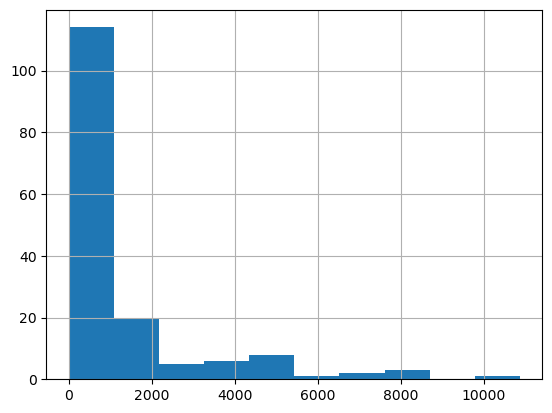

In [286]:
emax.hist()

In [170]:
print(emax.ss)

country
AE     114.0
AL     126.0
AM    2838.0
AO     243.0
AR      67.0
       ...  
VN      39.0
VU      70.0
ZA    5558.0
ZM    3779.0
ZW    4887.0
Name: elevation, Length: 160, dtype: float64


In [171]:
ediff.sort_values(ascending=False)

(160,)                  Series([], Name: elevation, dtype: float64)
----------------------  ---------------------------------------------
          type                   elevation
country                 country
PE       large          PE         10747.0
EC       large          EC          7822.0
MX       large          MX          7354.0
CN       large          CN          6893.0
US       large          US          5427.0
...        ...          ...            ...
HK       large          HK             0.0
GU       large          GU             0.0
GT       large          GT             0.0
GP       large          GP             0.0
ZW       large          ZW             0.0

[160 rows x 1 columns]  [160 rows x 1 columns]

<Axes: >

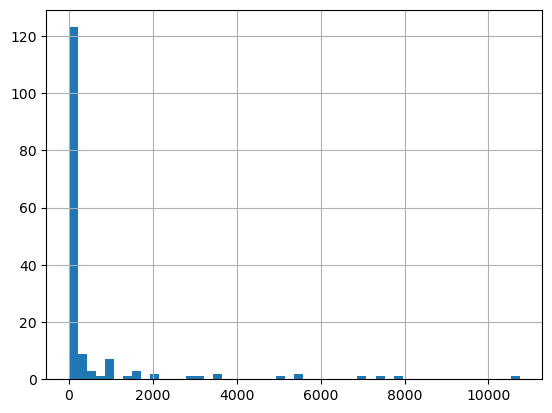

In [282]:
ediff.hist(bins=50)

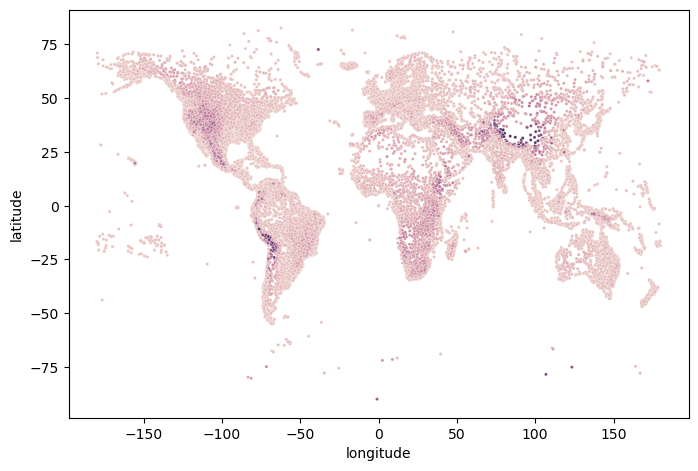

In [318]:
# sb.color_palette("rocket_r", as_cmap=True)
plt.figure(figsize=(8,5.3))
ax = mf.call(sb.scatterplot,x='longitude',y='latitude',s=5,hue='elevation')
ax.get_legend().remove()
plt.savefig('../muldataframe_paper/JOSS/jss-article-tex/airports.pdf')

In [172]:
from geopy.distance import distance

In [238]:
place=[42,42]

In [243]:
mf2 = mf.apply(lambda row:distance(row.iloc[-2:],place).km,axis=1)

In [244]:
mf3 = mf2.sort_values()

In [249]:
mf3

(68951,)                            Series([], Name: apply, dtype: object)
----------------------------------  ----------------------------------------
           type       name country                  apply
ident                               ident
GE-0007  medium   Ozurgeti      GE  GE-0007     13.786099
GE-0006   small   Kobuleti      GE  GE-0006     24.294137
GE-0010  medium     Senaki      GE  GE-0010     26.955916
UGKO     medium      David      GE  UGKO        44.479377
UGSB     medium     Batumi      GE  UGSB        54.590472
...         ...        ...     ...  ...               ...
NTAT     medium     Tubuai      PF  NTAT     17681.807678
NTGS      small    Marutea      PF  NTGS     17718.241038
NTTX      small    Moruroa      PF  NTTX     17763.767128
NTAV      small   Raivavae      PF  NTAV     17808.460274
NTGJ     medium  Totegegie      PF  NTGJ     17886.278807

[68951 rows x 3 columns]            [68951 rows x 1 columns]

In [210]:
mf3.mloc[{'type':'large'}]

/Users/qn/Documents/NuMedii_mac/Jandas/muldataframe/muldataframe/cmm.py:109: PerformanceWarning: indexing past lexsort depth may impact performance.
  ss = ss.loc[tuple(idx)]


(475,)                                                             Series([], Name: apply, dtype: object)
-----------------------------------------------------------------  ----------------------------------------
        type                                 name country  region                apply
ident                                                              ident
URSS   large          Sochi International Airport      RU  RU-KDA  URSS     232.261860
UGTB   large        Tbilisi International Airport      GE   GE-TB  UGTB     248.153881
UDYZ   large      Zvartnots International Airport      AM   AM-ER  UDYZ     287.860443
URRP   large         Platov International Airport      RU  RU-ROS  URRP     632.186387
UBBB   large  Heydar Aliyev International Airport      AZ   AZ-BA  UBBB     695.453005
...      ...                                  ...     ...     ...  ...             ...
NVVV   large     Bauerfield International Airport      VU  VU-SEE  NVVV   14292.438032
NZAA   large     

In [250]:
names['GE-0007']

'Ozurgeti Air Base'

In [144]:
for x,v in  mf['elevation'].groupby('country'):
    print(x,v)
    break

AD (2,)                                                                             Series([], Name: elevation, dtype: float64)
-------------------------------------------------------------------------------  ---------------------------------------------
             type                                               name country  \           elevation
ident                                                                            ident
AD-0001  heliport                          Terra Guindaldes Heliport      AD     AD-0001        NaN
AD-ALV   heliport  Andorra la Vella (Our Lady of Meritxell Hospit...      AD     AD-ALV      3450.0

        region
ident
AD-0001  AD-04
AD-ALV   AD-08


In [145]:
v.max()

3450.0

In [143]:
es

(244,)                                                                                                                                                                                                                                                                                                                                                                                                                        Series([], Name: elevation, dtype: float64)
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------  ---------------------------------------------
Empty DataFrame                                                                   

In [64]:
[x for x in df2['coordinates'] if not isinstance(x,str)]

[]

In [28]:
import time
import os
os.system(f'mkdir -p ../muldataframe_paper/replicate/data')
iter_count = 100
xf = pd.DataFrame(columns=['mul','pandas','pandas_build_idx'])
for rlen in [1e6,1e7]:
    rlen = int(rlen)
    xf.loc[rlen] = 0
    np.random.seed(123)
    df = pd.DataFrame(np.random.random((rlen,3)))
    for i in range(iter_count):
        if (i+1) % 10 == 0:
            print(i+1)
        rds = np.random.randint(0,rlen,3)
        rd1,rd3,rd2 = sorted(rds,reverse=True)
        # print(rd1,rd2,rd3)
        index = pd.DataFrame({'x':['a']*rd1+['b']*(rlen-rd1),
                            'y':['a']*rd2+['b']*(rlen-rd2),
                            'z':['a']*rd3+['b']*(rlen-rd3)})
        mf = MulDataFrame(df,index=index)
        t0 = time.time()
        res = mf.mloc[['a','b','a']]
        t1 = time.time()
        xf.loc[rlen,'mul'] += t1-t0


        df2 = df.copy()
        t0 = time.time()
        idx = pd.IndexSlice
        df2.index = pd.MultiIndex.from_frame(index)
        # df3 = df2.reorder_levels(order=[1,2,0])
        res = df2.loc[idx['a','b','a']]
        t1 = time.time()
        xf.loc[rlen,'pandas_build_idx'] += t1-t0

        t0 = time.time()
        res = df2.loc[idx['a','b','a']]
        t1 = time.time()
        xf.loc[rlen,'pandas'] += t1-t0

        df3 = df2.reset_index()
        df3.columns = [str(x) for x in df3.columns]
        os.system(f'mkdir -p ../muldataframe_paper/replicate/data/{rlen}')
        df3.to_feather(f'../muldataframe_paper/replicate/data/{rlen}/{i+1}.ft')
    # break

/var/folders/fh/dw4ym82j08l67xt8ndms1f_c0000gn/T/ipykernel_91169/3944947732.py:24: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5344851016998291' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  xf.loc[rlen,'mul'] += t1-t0
/var/folders/fh/dw4ym82j08l67xt8ndms1f_c0000gn/T/ipykernel_91169/3944947732.py:34: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.17890596389770508' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  xf.loc[rlen,'pandas'] += t1-t0
/var/folders/fh/dw4ym82j08l67xt8ndms1f_c0000gn/T/ipykernel_91169/3944947732.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.0003941059112548828' has dtype incompatible with int64, please explicitly cast to a 

10
20
30
40
50
60
70
80
90
100
10
20
30
40
50
60
70
80
90
100


In [30]:
xf/iter_count

,mul,pandas,pandas_build_idx
1000000,0.444120,0.182235,0.000391
10000000,4.200983,1.880299,0.000360


2.4444444444444446

In [33]:
pd.__version__

'2.2.0'

In [10]:
df3 = df2.reset_index()
df3.to_csv('../muldataframe_paper/replicate/df.txt',sep='\t',index=None)

3.9570188522338867
1.9009320735931396


In [63]:
pd.IndexSlice

In [38]:
key1 = object()
key2 = object()
dc = {key1:5}
dc[key2]

KeyError: <object object at 0x16a871cd0>

In [321]:
index = pd.DataFrame([[1,2],[3,6],[5,6]],
                     index=['a','b','b'],
                     columns=['x','y'])
columns = pd.DataFrame([[5,7],[3,6]],
                    index=['c','d'],
                    columns=['f','g'])
mf = MulDataFrame([[1,2],[8,9],[8,7]],
    index=index,columns=columns)

In [323]:
print(mf.sort_values('d'))

(3, 2)    g  7  6
          f  5  3
             c  d
--------  ---------
   x  y      c  d
a  1  2   a  1  2
b  5  6   b  8  7
b  3  6   b  8  9


In [279]:
df.index[pd.Index([2,1])]

Index(['b', 'b'], dtype='object')

In [273]:
del df.loc['a']

AttributeError: __delitem__

In [38]:
print(mf.mloc[[[True,False,True]]])

(2, 2)    g  7  6
          f  5  3
             c  d
--------  ---------
   x  y      c  d
a  1  2   a  1  2
b  5  6   b  8  7


In [54]:
~np.array([1,2])

array([-2, -3])

In [52]:
mf2 = mf.copy()
mf2.loc['a'] = [5,7]

In [65]:
mf2['c'] = [8,9,10]

In [73]:
mf3 = mf.copy()
mf3.mloc[{'x':3},{'f':5}] = 0 
print(mf3)

(3, 2)    g  7  6
          f  5  3
             c  d
--------  ---------
   x  y      c  d
a  1  2   a  1  2
b  3  6   b  0  9
b  5  6   b  8  7


In [74]:
mf3.mloc[[..., 2]] = [3,5]
print(mf3)

(3, 2)    g  7  6
          f  5  3
             c  d
--------  ---------
   x  y      c  d
a  1  2   a  3  5
b  3  6   b  0  9
b  5  6   b  8  7


In [26]:
mf2 = mf.iloc[:2]

In [29]:
mf2.index = mf2.index.iloc[:,1:]
mf2.columns = mf2.columns.iloc[:,[0]]

In [35]:
mf3 = mf2.copy()
mf3.pindex = ['a','c']

In [48]:
print(mf2 / mf2.df)

(2, 2)    f  5  3
             c  d
--------  -----------
   y           c    d
a  2      a  1.0  1.0
b  6      b  1.0  1.0


In [34]:
print(mf+mf2)

(3, 2)    g  7  6
          f  5  3
             c  d
--------  ---------
   x  y       c   d
a  1  2   a   2   4
b  3  6   b  16  18
b  5  6   b  16  16


In [25]:
(mf**2).iloc[1,0]

64

In [215]:
# index = pd.DataFrame([[1,2,'d'],
#                           [3,6,'d'],
#                           [5,6,'e']],
#                      index=['a','b','b'],
#                      columns=['x','y','y'])
index = pd.DataFrame([[1,2,'d'],
                          [3,6,'f'],
                          [5,6,'e']],
                     index=['a','b','b'],
                     columns=['x','y','y'])
columns = pd.DataFrame([[5,7],[3,6]],
                    index=['c','d'],
                    columns=['f','g'])
mf = MulDataFrame([[1,2],[8,9],[8,10]],
    index=index,columns=columns)

In [216]:
print(mf)

(3, 2)      g  7  6
            f  5  3
               c  d
----------  ---------
   x  y  y     c   d
a  1  2  d  a  1   2
b  3  6  f  b  8   9
b  5  6  e  b  8  10


In [97]:
tuple({'a':5,'b':6}.values())

(5, 6)

In [95]:
df.iloc[np.array([1,2])]

,,,c,d
x,y,y,,
3,6,d,8,9
5,6,e,8,10


In [15]:
df.index.get_level_values(0)[1]

1

In [217]:
idx = pd.MultiIndex.from_frame(index)
cols = pd.MultiIndex.from_frame(index)

In [218]:
df = mf.df
df.index = idx

In [219]:
ix = pd.IndexSlice

In [220]:
df

,,,c,d
x,y,y,,
1,2,d,1,2
3,6,f,8,9
5,6,e,8,10


In [221]:
df.loc[ix[[1,3],:,['e','f']],:]

,,,c,d
x,y,y,,
3,6,f,8,9


In [226]:
lendf.index.names

FrozenList(['x', 'y', 'y'])

In [204]:
arr = (slice(None),slice(None))
arr_idx = ix[slice(None),slice(None),'e']
df.loc[arr,'c'].shape

(3,)

In [210]:
df.loc[ix[1,2],:]

,c,d
y,,
d,1,2


In [77]:
mf.mloc[[...,...,'e']]

(2,)     y  e
         y  6
         x  5
            b
-------  ------
   f  g      b
c  5  7  c   8
d  3  6  d  10

In [6]:
mf2 = mf.copy()
mf2.index = mf2.index.iloc[:,:-1]

In [37]:
df = mf2.df

In [47]:
df2 = df.iloc[:,:]

In [48]:
df2.iloc[0,0] = 11
df

,c,d
aa,,
a,11,5
b,8,9
b,8,10


In [16]:
ss = pd.Series([],name='sum')

In [21]:
pd.DataFrame(ss).transpose().shape

(1, 0)

In [14]:
mf2.groupby('y').sum(axis=1)

InvalidIndexError: Reindexing only valid with uniquely valued Index objects

In [10]:
print(mf2.groupby('y',agg_mode='list',keep_primary=True).mean())

(2, 2)                   g  7  6
                         f  5  3
                            c  d
-----------------------  -----------
  primary_index       x       c    d
y                        y
2             a       1  2  1.0  2.0
6             b  [3, 5]  6  8.0  9.5


In [9]:
print(mf2.groupby('y',agg_mode='list').mean())

(2, 2)     g  7  6
           f  5  3
              c  d
---------  -----------
        x       c    d
y          y
2       1  2  1.0  2.0
6  [3, 5]  6  8.0  9.5


In [16]:
dd = mf.index

In [23]:
def abc(x,*args,y=5,**kwargs):
    print(args,kwargs)

In [25]:
abc(5,6,y=8,z=7)

(6,) {'z': 7}


In [14]:
print(mf2)

(3, 2)    g  7  6
          f  5  3
             c  d
--------  ---------
   x  y      c   d
a  1  2   a  1   2
b  3  6   b  8   9
b  5  6   b  8  10


In [18]:
for k, gp in mf2.groupby('y'):
    print(k,gp)

2 (1, 2)               g  7  6
                     f  5  3
                        c  d
-------------------  -------------------
               x  y                 c  d
primary_index        primary_index
a              1  2  a              1  2
6 (2, 2)               g  7  6
                     f  5  3
                        c  d
-------------------  --------------------
               x  y                 c   d
primary_index        primary_index
b              3  6  b              8   9
b              5  6  b              8  10


In [48]:
np.sum(mf.df.values,axis=None)

38

In [73]:
print(mf)

(3, 2)    g  7  6
          f  5  3
             c  d
--------  ---------
   x  y      c   d
a  1  2   a  1   2
b  3  6   b  8   9
b  5  6   b  8  10


In [77]:
print(mf.groupby('y',agg_mode='list',keep_primary=True).mean())

NotImplementedError: The function applied to a group MulDataFrame can only produce a A MulDataFrame, a MulSeries or a scalar. The function applied to a group MulSeries can only produce a MulSeries or a scalar.

In [75]:
print(mf.groupby('y',agg_mode='list',keep_primary=True).mean())

NotImplementedError: The function applied to a group MulDataFrame can only produce a A MulDataFrame, a MulSeries or a scalar. The function applied to a group MulSeries can only produce a MulSeries or a scalar.

In [76]:
print(mf.groupby('y',agg_mode='list').call(lambda df:df.sum().sum()))

(2,)       Series([], Name: <lambda>, dtype: object)
---------  -------------------------------------------
        x     <lambda>
y          y
2       1  2         3
6  [3, 5]  6        35


In [18]:
np.sum(mf.df)

/Users/qn/miniforge3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


c    17
d    18
dtype: int64

In [43]:
sf = mf.df.groupby(['c','d']).sum()
sf.shape

(3, 0)

In [45]:
for k, gp in mf.df.groupby(['c','d']):
    print(k,gp)

(1, 2)    c  d
a  1  2
(8, 7)    c  d
b  8  7
(8, 9)    c  d
b  8  9


In [46]:
isinstance(k,tuple)

True

In [4]:
print(mf.loc['b'])

(2, 2)      g  7  6
            f  5  3
               c  d
----------  ---------
   x  y  y     c   d
b  3  6  d  b  8   9
b  5  6  e  b  8  10


In [4]:
index = pd.DataFrame([[1,2],[3,6],[5,6]],
                     index=['a','b','b'],
                     columns=['x','y'])
columns = pd.DataFrame([[5,7],[3,6]],
                     index=['c','d'],
                     columns=['f','g'])
md = MulDataFrame([[1,2],[8,9],[8,7]],index=index,
                  columns=columns)
mf = md

In [38]:
mf.log1p

<function muldataframe.MulDataFrame.MulDataFrame.__getattr__.<locals>.func(*args, **kwargs)>

In [9]:
mf.sum()

(2,)     Series([], Name: sum, dtype: object)
-------  --------------------------------------
   f  g     sum
c  5  7  c   17
d  3  6  d   18

In [36]:
mf.diff()

,c,d
a,NaN,NaN
b,7.0,7.0
b,0.0,-2.0


In [23]:
print(mf.log1p())

(3, 2)    g  7  6
          f  5  3
             c  d
--------  ---------------------
   x  y             c         d
a  1  2   a  0.693147  1.098612
b  3  6   b  2.197225  2.302585
b  5  6   b  2.197225  2.079442


In [19]:
print(mf.min())

(2,)     Series([], Name: min, dtype: object)
-------  --------------------------------------
   f  g     min
c  5  7  c    1
d  3  6  d    2


In [16]:
mf.min()

(2,)     Series([], Name: min, dtype: object)
-------  --------------------------------------
   f  g     min
c  5  7  c    1
d  3  6  d    2

In [6]:
print(mf)

(3, 2)    g  7  6
          f  5  3
             c  d
--------  ---------
   x  y      c  d
a  1  2   a  1  2
b  3  6   b  8  9
b  5  6   b  8  7


In [8]:
print(mf.df + mf)

(3, 2)    g  7  6
          f  5  3
             c  d
--------  ---------
   x  y       c   d
a  1  2   a   2   4
b  3  6   b  16  18
b  5  6   b  16  14


In [23]:
midx = pd.MultiIndex.from_frame(mf.index)
df = mf.df
df.index = midx

In [37]:
idx = pd.IndexSlice

In [5]:
print(mf)

(3, 2)    g  7  6
          f  5  3
             c  d
--------  ---------
   x  y      c  d
a  1  2   a  1  2
b  3  6   b  8  9
b  5  6   b  8  7


In [11]:
mf.iloc[:,0].iloc[:2]

(2,)     g  7
         f  5
            c
-------  ------
   x  y     c
a  1  2  a  1
b  3  6  b  8

In [141]:
df.loc[idx[:,6],:]

,,c,d
x,y,,
3,6,8,9
5,6,8,7


In [148]:
df.loc[idx[:,2],:].shape

(1, 2)

In [153]:
print(mf)

(3, 2)    g  7  6
          f  5  3
             c  d
--------  ---------
   x  y      c  d
a  1  2   a  1  2
b  3  6   b  8  9
b  5  6   b  8  7


In [7]:
mf.mloc[[1,[2,6]]]

(2,)     y  2
         x  1
            a
-------  ------
   f  g     a
c  5  7  c  1
d  3  6  d  2

In [162]:
df.loc[idx[3,[2,6]],:]

,,c,d
x,y,,
3,6,8,9


In [156]:
df

,,c,d
x,y,,
1,2,1,2
3,6,8,9
5,6,8,7


In [145]:
dff = df.iloc[:,0]

In [147]:
dff.loc[idx[1]]

y
2    1
Name: c, dtype: int64

In [122]:
df2 = pd.DataFrame([[5,3],
                    [1,2],
                    [8,9],
                    [8,7]])
index = pd.MultiIndex.from_frame(
    pd.DataFrame([[7,6],
                  [1,2],
                  [3,6],
                  [3,5]])
)
df2.index = index
# df2.index = pd.MultiIndex.from_product([["A", "B"], ["c", "d"]])

In [130]:
df2.loc[idx[[1,3],2],:]

,,0,1
0,1,,
1,2,1,2


In [133]:
df2.loc[idx[:,2],:]

,,0,1
0,1,,
1,2,1,2


In [176]:
x = 5
x.bit_length()

3

In [185]:
print(mf.query(index='y==6'))

(2, 2)    g  7  6
          f  5  3
             c  d
--------  ---------
   x  y      c  d
b  3  6   b  8  9
b  5  6   b  8  7


In [202]:
ms = mf.iloc[:,0]

In [230]:
mf.iloc[:,0]

(3,)     g  7
         f  5
            c
-------  ------
   x  y     c
a  1  2  a  1
b  3  6  b  8
b  5  6  b  8

In [12]:
ms = mf.iloc[:,0]

In [13]:
def reorder(ss):
    return ss.iloc[::-1]

In [14]:
ms3 = ms.iloc[:2].call(reorder)

In [15]:
display(ms.iloc[:2])

(2,)     g  7
         f  5
            c
-------  ------
   x  y     c
a  1  2  a  1
b  3  6  b  8

In [6]:
mf2 = mf.iloc[:2]

In [7]:
mf2.pcolumns = ['a','b']

In [14]:
print(mf2)

(2, 2)    g  7  6
          f  5  3
             a  b
--------  ---------
   x  y      a  b
a  1  2   a  1  2
b  3  6   b  8  9


In [8]:
def sum(df,axis=0):
    return df.sum(axis=axis)

def sum2(df):
    return df.sum()


NameError: name 'mf' is not defined

In [10]:
mf2.call(sum)

(2,)     Series([], Name: sum, dtype: object)
-------  --------------------------------------
   f  g     sum
a  5  7  a    9
b  3  6  b   11

In [11]:
mf2.call(sum,axis=1)

(2,)     Series([], Name: sum, dtype: object)
-------  --------------------------------------
   x  y     sum
a  1  2  a    3
b  3  6  b   17

In [12]:
mf2.call(sum2)

NotImplementedError: 

In [39]:
df = mf2.df

In [40]:
import inspect
inspect.signature(df.sum).parameters['axis'].default

0

In [23]:
mf2.call(sum)

NotImplementedError: 

In [20]:
print(mf2)

(2, 2)    g  7  6
          f  5  3
             a  b
--------  ---------
   x  y      a  b
a  1  2   a  1  2
b  3  6   b  8  9


In [192]:
cc = mf.call(lambda df:df.sum())

In [199]:
def poly(df,a,b=0):
    return df.sum(axis=1)*a+b

In [201]:
def k(x):
    return x
k(5,a=3)


TypeError: k() got an unexpected keyword argument 'a'

In [200]:
print(mf.call(poly,2,b=1))

(3,)     Series([], Name: poly, dtype: object)
-------  ---------------------------------------
   x  y     poly
a  1  2  a     7
b  3  6  b    35
b  5  6  b    31


In [194]:
cc.pname

'<lambda>'

In [180]:
df.query('c.str.contains(8)',engine='python')

AttributeError: Can only use .str accessor with string values!

In [164]:
print(mf)

(3, 2)    g  7  6
          f  5  3
             c  d
--------  ---------
   x  y      c  d
a  1  2   a  1  2
b  3  6   b  8  9
b  5  6   b  8  7


In [113]:
df2.loc[(["A", "B"], ["c", "d"])] 

KeyError: "None of [Index(['c', 'd'], dtype='object')] are in the [columns]"

In [103]:
s = pd.Series(
    [1, 2, 3, 4],
    index=pd.MultiIndex.from_product([["A", "B"], ["c", "d"]]),
)
s.loc[(["A", "B"], ["c", "d"])] 

A  c    1
   d    2
B  c    3
   d    4
dtype: int64

In [108]:
s.index

MultiIndex([('A', 'c'),
            ('A', 'd'),
            ('B', 'c'),
            ('B', 'd')],
           )

In [109]:
df2.index

MultiIndex([('A', 'c'),
            ('A', 'd'),
            ('B', 'c'),
            ('B', 'd')],
           )

In [100]:
pd.__version__

'2.2.0'

In [99]:
df2.loc[(["A", "B"], ["c", "d"])]

KeyError: "None of [Index(['c', 'd'], dtype='object')] are in the [columns]"

In [47]:
df

,,c,d
x,y,,
1,2,1,2
3,6,8,9
5,6,8,7


KeyError: 2

In [42]:
df.loc[]

,,c,d
x,y,,
1,2,1,2
3,6,8,9


In [34]:
df

,,c,d
x,y,,
1,2,1,2
3,6,8,9
5,6,8,7


In [13]:
df = pd.DataFrame([[1,2],[8,9]],index=['a','b'],columns=['d','c'])
mf2 = MulDataFrame(df, index=index,
    columns=columns, index_init='align',
    columns_init='align')

In [21]:
pd.DataFrame({'a':pd.Series([1],index=['k']),
              'b':pd.Series([1],index=['c'])})

,a,b
c,NaN,1.0
k,1.0,NaN


In [15]:
print(mf2)

(3, 2)    g  7  6
          f  5  3
             c  d
--------  ---------
   x  y      c  d
a  1  2   a  2  1
b  3  6   b  9  8
b  5  6   b  9  8


In [104]:
print(mf.mloc[{'y':[2,6],'x':[3]}])

(1, 2)    g  7  6
          f  5  3
             c  d
--------  ---------
   x  y      c  d
b  3  6   b  8  9


In [106]:
print(mf.mloc[[[3],6]])

(1, 2)    g  7  6
          f  5  3
             c  d
--------  ---------
   x  y      c  d
b  3  6   b  8  9


In [93]:
print(mf.mloc[{'y':[2,6],'x':3}])

(2,)     y  6
         x  3
            b
-------  ------
   f  g     b
c  5  7  c  8
d  3  6  d  9


In [89]:
mf.mloc[[3,6]]

(2,)     y  6
         x  3
            b
-------  ------
   f  g     b
c  5  7  c  8
d  3  6  d  9

In [85]:
print(mf.mloc[[..., 6],[3]])

(2,)     g  6
         f  3
            d
-------  ------
   x  y     d
b  3  6  b  9
b  5  6  b  7


In [10]:
mf2 = mf.copy()
mf2.index.index = ['d','e',5]
print(mf2)

(3, 2)    g  7  6
          f  5  3
             c  d
--------  ---------
   x  y      c  d
d  1  2   d  1  2
e  3  6   e  8  9
5  5  6   5  8  7


In [7]:
mf['d'] < 9

(3,)     g  6
         f  3
            d
-------  --------
   x  y         d
a  1  2  a   True
b  3  6  b  False
b  5  6  b   True

In [113]:
print(mf.query('d < 9',index='y==6',columns='f==5'))

(1, 1)    g  7
          f  5
             c
--------  ------
   x  y      c
b  5  6   b  8


In [109]:
mf2.mindex.set_index('x',inplace=True)
print(mf2)

(3, 2)    g  7  6
          f  5  3
             c  d
--------  ---------
   y         c  d
x         x
1  2      1  1  2
3  6      3  8  9
5  6      5  8  7


In [79]:
print(md.mindex)

   x  y
a  1  2
b  3  6
b  5  6


In [75]:
print(md.loc['b'])

(2, 2)    g  7  6
          f  5  3
             c  d
--------  ---------
   x  y      c  d
b  3  6   b  8  9
b  5  6   b  8  7


In [64]:
type(np.array([1,2,3]))

numpy.ndarray

In [67]:
isinstance(slice(None),slice)

True

In [65]:
isinstance(np.array([1,2,3]),np.ndarray)

True

In [56]:
df = md.df
df

,c,d
a,1,2
b,8,9
b,8,7


In [54]:
ss = df.iloc[:,0]
ss[ss>1]

b    8
b    8
Name: c, dtype: int64

In [61]:
ss.loc[ss>1]

b    8
b    8
Name: c, dtype: int64

In [58]:
df[[True,False,True]]

,c,d
a,1,2
b,8,7


In [59]:
df[df['c'] > 1]

,c,d
b,8,9
b,8,7


In [53]:
df.loc[:,df.loc['a']>1]

,d
a,2
b,9
b,7


In [8]:
print(md.insert('e',[7,8,9],inplace=False))

(3, 3)    g  7  6  None
          f  5  3  None
             c  d     e
--------  ---------------
   x  y      c  d  e
a  1  2   a  1  2  7
b  3  6   b  8  9  8
b  5  6   b  8  7  9


In [16]:
eq([None],[np.nan])
[np.nan]*3

[nan, nan, nan]

In [36]:
x = slice(None)
x == slice(None)

True

In [24]:
df = md.df

In [25]:
df.loc['g'] = [None]*2

In [30]:
df2 = df.transpose()
del df2['b']

In [34]:
ss = df.iloc[:,0]
del ss['b']
ss

IndexError: arrays used as indices must be of integer (or boolean) type

In [31]:
df.insert(2,'e',[None]*3)
df

pp,c,d,e
a,1,2,None
b,8,9,None
b,8,7,None


In [17]:
# df.index.name = 'kk'
df.columns.name = 'pp'
print(df)

pp  c  d
a   1  2
b   8  9
b   8  7


In [18]:
ss = df.iloc[:,0]

In [22]:
ss.loc['c'] = 5

In [10]:
df.loc['e'] = (5,6)

In [11]:
df

,c,d
a,1,2
b,8,9
b,8,7
d,5,6
e,5,6


In [6]:
print(md>5)

(3, 2)    g  7  6
          f  5  3
             c  d
--------  ---------------
   x  y          c      d
a  1  2   a  False  False
b  3  6   b   True   True
b  5  6   b   True   True


/Users/qn/Documents/NuMedii_mac/Jandas/muldataframe/muldataframe/ValFrameBase.py:10: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  self.parent = parent


In [7]:
cc = md > 5
print(cc)

(3, 2)    g  7  6
          f  5  3
             c  d
--------  ---------------
   x  y          c      d
a  1  2   a  False  False
b  3  6   b   True   True
b  5  6   b   True   True


/Users/qn/Documents/NuMedii_mac/Jandas/muldataframe/muldataframe/ValFrameBase.py:10: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  self.parent = parent


In [12]:
md+2

TypeError: unsupported operand type(s) for +: 'MulDataFrame' and 'int'

In [8]:
import tabulate
tabulate.PRESERVE_WHITESPACE = True

In [31]:
str(index)

'   x  y\na  1  2\nb  3  6\nb  5  6'

In [45]:
def tx(x):
    xs = str(x.transpose())
    lines = xs.split('\n')
    lines = lines[1:]+[lines[0]]
    return '\n'.join(lines)

In [47]:
print(tabulate.tabulate([[str(index),str(md.df)]],
               headers=['(3,2)',str(tx(columns))]))

(3,2)    f  5  3
         g  7  6
            c  d
-------  ---------
   x  y     c   d
a  1  2  a  1   2
b  3  6  b  8   9
b  5  6  b  8  10


In [89]:
ss = pd.Series([1,2,3])
ds = pd.DataFrame(ss)
ds.columns = [None]
ds

,None
0,1
1,2
2,3


In [85]:
print(str(ss))

0    1
1    2
2    3
Name: 5, dtype: int64


In [83]:
str(md.df)

'   c   d\na  1   2\nb  8   9\nb  8  10'

In [64]:
cc = pd.DataFrame(columns=['a','b'])
cc.shape

(0, 2)

In [68]:
ck = pd.DataFrame(index=cc.index)
ck.shape

(0, 0)

In [75]:
str(cc)

'Empty DataFrame\nColumns: [a, b]\nIndex: []'

In [44]:
print(tx(columns))

f  5  3
g  7  6
   c  d


In [10]:
print(tabulate.tabulate([['  a','  b']],
               headers=[' k',' f'],
               tablefmt='simple'))

 k     f
----  ----
  a     b


In [41]:
str(index).replace(' ','@')

'@@@x@@y\na@@1@@2\nb@@3@@6\nb@@5@@6'

In [9]:
print(tabulate.tabulate([['a','e'],['b','x']],
               headers=['c','d']))

c    d
---  ---
a    e
b    x


In [34]:
print(str(index))

   x  y
a  1  2
b  3  6
b  5  6


In [5]:
df = md.df

In [ ]:
df.insert

In [16]:
df.insert(0,None,5,allow_duplicates=True)

In [18]:
ss = df['c']

In [25]:
df.index.name

In [27]:
ss = df['c']
ss.reset_index(inplace=True)

TypeError: Cannot reset_index inplace on a Series to create a DataFrame

In [24]:
pd.DataFrame(df.index)

,0
0,a
1,b
2,b


In [22]:
pd.DataFrame(ss).transpose()

,a,b,b
c,1,8,8


In [13]:
df.insert(0,'b',5,allow_duplicates=True)

In [14]:
df

,b,b,a,c,d
a,5,5,1,1,2
b,5,5,2,8,9
b,5,5,3,8,10


In [58]:
x = np.array([[1,2],[5,6]])
y = x.copy().T
x[0,0] = 5

In [59]:
y

array([[1, 5],
       [2, 6]])

In [41]:
df = md.df

In [45]:
list(df.transpose().groupby(df.index,axis=1))

/var/folders/fh/dw4ym82j08l67xt8ndms1f_c0000gn/T/ipykernel_28043/667695596.py:1: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  list(df.transpose().groupby(df.index,axis=1))


[('a',
     a
  c  1
  d  2),
 ('b',
     b   b
  c  8   8
  d  9  10)]

In [48]:
df.groupby(df.index).mean()

,c,d
a,1.0,2.0
b,8.0,9.5


In [52]:
df.transpose().groupby(df.index)

ValueError: Grouper and axis must be same length

In [34]:
md.df.mean(axis=1)

a    1.5
b    8.5
b    9.0
dtype: float64

In [40]:
pd.DataFrame(md.df.iloc[:2])

,c,d
a,1,2
b,8,9


In [38]:
md.__df = [1,2]
md.__df

[1, 2]

In [33]:
md * pd.Series([2,2],index=['d','c'])

df:
    c   d
a   2   4
b  16  18
b  16  20

index:
   x  y
a  1  2
b  3  6
b  5  6

columns:
   f  g
c  5  7
d  3  6

In [30]:
md + pd.DataFrame([[1,1],[1,1],[1,1]],index=['a','b','b'],
                  columns=['c','d'])

NotImplementedError: 

In [20]:
md

df:
   c   d
a  1   2
b  8   9
b  8  10

index:
   x  y
a  1  2
b  3  6
b  5  6

columns:
   f  g
c  5  7
d  3  6

In [14]:
import inspect
hasattr(np.mean,'__call__')

# type(np.mean) == types.MethodType

True

In [5]:
md.iloc[:,0]

ss:
a    1
b    8
b    8
Name: c, dtype: int64

index:
   x  y
a  1  2
b  3  6
b  5  6

name:
f    5
g    7
Name: c, dtype: int64

In [43]:
len(md.df.iloc[0])

2

In [8]:
df = md.df

In [28]:
df.index.name = 'xx'

In [29]:
lf = df.melt(value_vars=['c','d'],ignore_index=False)

In [31]:
lf

,variable,value
xx,,
a,c,1
b,c,8
b,c,8
a,d,2
b,d,9
b,d,10


In [33]:
x = True
x is True

True

In [39]:
x = 5
hasattr(md,'__pandas_priority__')

True

In [35]:
x = np.array([[1,2],[3,4],[5,6]])
np.ravel(x)

array([1, 2, 3, 4, 5, 6])

In [14]:
def abc(x=None,y=None,**kwargs):
    print(x,y,kwargs)

In [18]:
abc(5,c=3)

5 None {'c': 3}


In [12]:
df.query('index == "b"')

,c,d
b,8,9
b,8,10


In [6]:
md.set_index('c',drop=True)

df:
    d
a   2
b   9
b  10

index:
   x  y  c
a  1  2  1
b  3  6  8
b  5  6  8

columns:
   f  g
d  3  6

In [72]:
df = md.df

In [49]:
df.drop_duplicates('c')

,c,d
a,1,2
b,8,9


In [26]:
md.drop_duplicates(['c'])

df:
   c  d
a  1  2
b  8  9

index:
   x  y
a  1  2
b  3  6

columns:
   f  g
c  5  7
d  3  6

In [24]:
md.loc['b']

df:
   c   d
b  8   9
b  8  10

index:
   x  y
b  3  6
b  5  6

columns:
   f  g
c  5  7
d  3  6

In [56]:
class A():
    def __init__(self, x):
        self.x = x
        
    def f(self):
        print(self.x)

class B(A):
    def __init__(self, x):
        super().__init__(x)
    def f(self):
        print(self.x*2)

In [92]:
x = pd.Series([1,2,2])
x.loc[~x.duplicated()]

0    1
1    2
dtype: int64

In [96]:
df.values[[False,True,False]]

array([[8, 9]])

In [28]:
x = pd.Series([1,2,3],index=['a','b','b'])


In [30]:
x.shape

1

In [115]:
pd.concat([df,x],axis=1)

,c,d,0
a,1,2,1
b,8,9,2
b,8,10,3


In [91]:
x.duplicated()

0    False
1    False
2     True
dtype: bool

In [66]:
b = B(3)
b.f()
super(B,b).f()

6
3


In [12]:
class LittleMeta(type):
    def __new__(cls, clsname, superclasses, attributedict):
        print("clsname: ", clsname)
        print("superclasses: ", superclasses)
        print("attributedict: ", attributedict)
        return type.__new__(cls, clsname, superclasses, attributedict)
    def __init__(cls, clsname, superclasses, attributedict):
        print("init clsname: ", clsname)
        print("init superclasses: ", superclasses)
        print("init attributedict: ", attributedict)
        return type.__init__(cls, clsname, superclasses, attributedict)
    def abc(self):
        return "abc"

In [15]:
from abc import ABC,abstractmethod

class A(ABC):
    def __init__(self, x):
        self.x = x
    
    @classmethod
    def f(self):
        return self.x + 1
    
    @abstractmethod
    def f2(self):
        return self.x + 1
    
    def f3(self):
        return self.x + 1

In [16]:
k = A(5)

TypeError: Can't instantiate abstract class A with abstract method f2

In [5]:
dict(A.__dict__)

{'__module__': '__main__',
 '__init__': <function __main__.A.__init__(self, x)>,
 'f': <classmethod(<function A.f at 0x16aee9c60>)>,
 'f2': <function __main__.A.f2(self)>,
 'f3': <function __main__.A.f3(self)>,
 '__dict__': <attribute '__dict__' of 'A' objects>,
 '__weakref__': <attribute '__weakref__' of 'A' objects>,
 '__doc__': None,
 '__abstractmethods__': frozenset({'f2'}),
 '_abc_impl': <_abc._abc_data at 0x16aefbdc0>}

In [18]:
abc = type('abc',(ABC,),dict(A.__dict__))

In [19]:
abc(5)

TypeError: Can't instantiate abstract class abc with abstract method f2

In [21]:
class A(pd.DataFrame,metaclass=LittleMeta):
    def f(self):
        print('a')

clsname:  A
superclasses:  (<class 'pandas.core.frame.DataFrame'>,)
attributedict:  {'__module__': '__main__', '__qualname__': 'A', 'f': <function A.f at 0x16b63ae80>}
init clsname:  A
init superclasses:  (<class 'pandas.core.frame.DataFrame'>,)
init attributedict:  {'__module__': '__main__', '__qualname__': 'A', 'f': <function A.f at 0x16b63ae80>}


In [20]:
class A:
    pass

In [9]:
index = pd.DataFrame([[1,2],[3,6],[5,6]],
                     index=['a','b','b'],
                     columns=['x','y'])
df =pd.DataFrame([[1,2],[8,9],[8,10]],index=pd.MultiIndex.from_frame(index))

In [11]:
for k, row in df.iterrows():
    print(k,row)

(1, 2) 0    1
1    2
Name: (1, 2), dtype: int64
(3, 6) 0    8
1    9
Name: (3, 6), dtype: int64
(5, 6) 0     8
1    10
Name: (5, 6), dtype: int64


In [17]:
xf = pd.DataFrame([[1,2],[3,4],[5,6]],index=['a','b','b'])

In [18]:
xf.groupby()

TypeError: You have to supply one of 'by' and 'level'

In [14]:
row

0     8
1    10
Name: (5, 6), dtype: int64

In [19]:
def fa():
    pass
fa.__name__

'fa'

In [14]:
df = md.df
df.index = pd.MultiIndex.from_frame(index)
df.columns = pd.MultiIndex.from_frame(columns)

In [22]:
df

,f,5,3
,g,7,6
x,y,,
1,2,1,2
3,6,8,9
5,6,8,10


In [29]:
df.index.to_frame(index=False)

,x,y
0,1,2
1,3,6
2,5,6


In [30]:
vals = df.values
vals[0,0]

1

In [40]:
df

[autoreload of muldataframe.util failed: Traceback (most recent call last):
  File "/Users/qn/miniforge3/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/Users/qn/miniforge3/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 475, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "/Users/qn/miniforge3/lib/python3.11/importlib/__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 621, in _exec
  File "<frozen importlib._bootstrap_external>", line 936, in exec_module
  File "<frozen importlib._bootstrap_external>", line 1074, in get_code
  File "<frozen importlib._bootstrap_external>", line 1004, in source_to_code
  File "<frozen importlib._bootstrap>", line 241, in _call_with_frames_removed
  File "/Users/qn/Documents/NuMedii_mac/Jandas/muldataframe/muldataframe/util.py", line 47
    pass
    ^^^^

,c,d
xx,,
a,1,2
b,8,9
b,8,10


In [37]:
x = md.__class__.__name__

In [39]:
md.xx